<div align="center">
    <a href="https://github.com/innat/medic-ai">
        <img src="https://i.imgur.com/nWOYfUO.png" width="350">
    </a>
</div>

## About

- It is starter designed for **Vesuvius Challenge - Surface Detection** in kaggle.
- We will utilize [Medic-AI](https://github.com/innat/medic-ai), a high-performance library built on Keras 3 tailored for 2D and 3D medical image analysis. Thanks to its multi-backend architecture, it operates seamlessly across `tensorflow`, `torch`, and `jax`. This flexibility allows developers, including dedicated `torch` users to integrate state-of-the-art 2D or 3D segmentation models directly into their existing training workflows. One key architectural detail to note: Medic-AI adopts the (`depth, y, x, channel`) convention for input shapes. [This guide](https://www.kaggle.com/code/ipythonx/medicai-x-isic-2017-starter-x-binary-segmentation) demonstrates how to plug-and-play these capabilities into your own pure `torch` projects.
- The official documentaiton of [`Medic-AI`](https://github.com/innat/medic-ai) is bit out-dated at the moment, and so to get up-to-date documentation, please refer to the GitHub readme page created for each model, i.e. [segormer](https://github.com/innat/medic-ai/blob/main/medicai/models/segformer/README.md), [trans-unet](https://github.com/innat/medic-ai/blob/main/medicai/models/transunet/README.md), [unetr++](https://github.com/innat/medic-ai/blob/main/medicai/models/unetr_plus_plus/README.md), [swin-unetr](https://github.com/innat/medic-ai/blob/main/medicai/models/swin/README.md#swin-unetr), [upernet](https://github.com/innat/medic-ai/blob/main/medicai/models/upernet/README.md), [convnext](https://github.com/innat/medic-ai/blob/main/medicai/models/convnext/README.md) etc.
- Since [medicia](https://github.com/innat/medic-ai) is a new project, any feedback, suggestions, or contributions to help make it more reliable, robust, and improved are highly appreciated.

## Code

- **Training**: This notebook is the main training code, updated time to time. It uses `jax` backend. To use other backend (i.e., `torch`), see [this](https://www.kaggle.com/code/ipythonx/inference-vesuvius-surface-3d-detection).
-  **Inference**: The inference code can be found here: [[Inference] Vesuvius Surface 3D Detection](https://www.kaggle.com/code/ipythonx/inference-vesuvius-surface-3d-detection)

In [1]:
from IPython.display import clear_output

# This is required for TPU training at the moment in kaggel env with Jax backend.
!pip install tensorflow -qU

var="/kaggle/input/vsdetection-packages-offline-installer-only/whls"
!pip install \
    "$var"/keras_nightly-3.12.0.dev2025100703-py3-none-any.whl \
    --no-index \
    --find-links "$var"

clear_output()

In [2]:
# To get up-to-date feature, installing from scource is safe.
!pip install git+https://github.com/innat/medic-ai.git -q

# Installing is optional, we'll be using `tfrecord` format instead of `tif`.
# !pip install imagecodecs tifffile -q


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
import os, warnings

os.environ["KERAS_BACKEND"] = "jax"
warnings.filterwarnings('ignore')

In [4]:
import glob
import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

# mainly for training API
import keras
from keras import ops
from keras.optimizers import SGD, AdamW, Muon
from keras.optimizers.schedules import CosineDecay, PolynomialDecay

# only for tf.data API
import tensorflow as tf

# mainly for 3D or 2D models, transformation, loss, metrics etc
import medicai
from medicai.transforms import (
    Compose,
    NormalizeIntensity,
    ScaleIntensityRange,
    Resize,
    RandShiftIntensity,
    RandRotate90,
    RandRotate,
    RandFlip,
    RandCutOut,
    RandSpatialCrop
)
from medicai.layers import ResizingND
from medicai.models import (
    UNet, SegFormer, TransUNet, SwinUNETR, UPerNet, ConvNeXtV2Tiny, UNETRPlusPlus
)
from medicai.losses import (
    SparseDiceCELoss, SparseTverskyLoss
)
from medicai.metrics import SparseDiceMetric
from medicai.callbacks import SlidingWindowInferenceCallback
from medicai.utils.inference import SlidingWindowInference

In [5]:
# due to distributed training only
keras.config.disable_flash_attention()

# reproducibility
keras.utils.set_random_seed(101)

# distributed config
devices = keras.distribution.list_devices()
data_parallel = keras.distribution.DataParallel(devices=devices)
keras.distribution.set_distribution(data_parallel)
total_device = len(devices)

print(f'detected devices: {devices}')
print(f'total device: {total_device}')

E0000 00:00:1768313018.317190      12 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:238


detected devices: ['tpu:0', 'tpu:1', 'tpu:2', 'tpu:3', 'tpu:4', 'tpu:5', 'tpu:6', 'tpu:7']
total device: 8


In [6]:
keras.version(), keras.config.backend(), medicai.version()

('3.12.0.dev2025100703', 'jax', '0.0.3')

## Data Loader

In [7]:
input_shape=(128, 128, 128)
batch_size=1 * total_device
num_classes=3

# Each tfrecord contains 6 samples, total 786 samples.
num_samples = 780
epochs = 200

**TFRecord Decoder**

In [8]:
def parse_tfrecord_fn(example):
    feature_description = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([], tf.string),
        "image_shape": tf.io.FixedLenFeature([3], tf.int64),
        "label_shape": tf.io.FixedLenFeature([3], tf.int64),
    }
    parsed_example = tf.io.parse_single_example(example, feature_description)
    image = tf.io.decode_raw(parsed_example["image"], tf.uint8)
    label = tf.io.decode_raw(parsed_example["label"], tf.uint8)
    image_shape = tf.cast(parsed_example["image_shape"], tf.int64)
    label_shape = tf.cast(parsed_example["label_shape"], tf.int64)
    image = tf.reshape(image, image_shape)
    label = tf.reshape(label, label_shape)
    return image, label

**Preprocessing and Augmentation**

In [9]:
def prepare_inputs(image, label):
    # Add channel dimension
    image = image[..., None] # (D, H, W, 1)
    label = label[..., None] # (D, H, W, 1)

    # Convert to float32
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.float32)
    return image, label

In [10]:
def train_transformation(image, label):
    data = {"image": image, "label": label}
    pipeline = Compose([
        ## Geometric transformation
        RandSpatialCrop(
            keys=["image", "label"],
            roi_size=input_shape,
            random_center=True,
            random_size=False,
            invalid_label=2,         
            min_valid_ratio=0.5,     
            max_attempts=10
        ),
        RandFlip(keys=["image", "label"], spatial_axis=[0], prob=0.5),
        RandFlip(keys=["image", "label"], spatial_axis=[1], prob=0.5),
        RandFlip(keys=["image", "label"], spatial_axis=[2], prob=0.5),
        RandRotate90(
            keys=["image", "label"], 
            prob=0.4, 
            max_k=3, 
            spatial_axes=(0, 1)
        ),
        RandRotate(
            keys=["image", "label"], 
            factor=0.2, 
            prob=0.7, 
            fill_mode="crop",
        ),

        ## Intensiry transformation
        # ScaleIntensityRange(
        #     keys=["image"],
        #     a_min = 0,
        #     a_max = 255,
        #     b_min = 0,
        #     b_max = 1,
        #     clip = True,
        # ),
        NormalizeIntensity(
            keys=["image"], 
            nonzero=True,
            channel_wise=False
        ),

        RandShiftIntensity(
            keys=["image"], offsets=0.10, prob=0.5
        ),

        ## Spatial transformation 
        RandCutOut(
            keys=["image", "label"],
            invalid_label=2, 
            mask_size=[
                input_shape[1]//4,
                input_shape[2]//4
            ],
            fill_mode="constant", # "constant", "gaussian"
            cutout_mode='volume', # "slice", "volume"
            prob=0.8,
            num_cuts=5,
        ),
    ])
    result = pipeline(data)
    return result["image"], result["label"]


def val_transformation(image, label):
    data = {"image": image, "label": label}
    pipeline = Compose([
        # ScaleIntensityRange(
        #     keys=["image"],
        #     a_min = 0,
        #     a_max = 255,
        #     b_min = 0,
        #     b_max = 1,
        #     clip = True,
        # ),
        NormalizeIntensity(
            keys=["image"], 
            nonzero=True,
            channel_wise=False
        ),
    ])
    result = pipeline(data)
    return result["image"], result["label"]


In [11]:
def tfrecord_loader(tfrecord_pattern, batch_size=1, shuffle=True):
    dataset = tf.data.TFRecordDataset(
        tf.io.gfile.glob(tfrecord_pattern)
    )
    dataset = dataset.shuffle(buffer_size=100) if shuffle else dataset 
    dataset = dataset.map(
        parse_tfrecord_fn, num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.map(
        prepare_inputs,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if shuffle:
        dataset = dataset.map(
            train_transformation,
            num_parallel_calls=tf.data.AUTOTUNE
        )
    else:
        dataset = dataset.map(
            val_transformation,
            num_parallel_calls=tf.data.AUTOTUNE
        )
    dataset = dataset.batch(batch_size, drop_remainder=shuffle)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

In [12]:
all_tfrec = sorted(
    glob.glob("/kaggle/input/vesuvius-tfrecords/*.tfrec"),
    key=lambda x: int(x.split("_")[-1].replace(".tfrec", ""))
)

val_idx = -1
val_patterns = [all_tfrec[val_idx]]
train_patterns = [
    f for i, f in enumerate(all_tfrec) if i != len(all_tfrec) + val_idx
]

train_ds = tfrecord_loader(
    train_patterns, batch_size=batch_size, shuffle=True
)
val_ds = tfrecord_loader(
    val_patterns, batch_size=1, shuffle=False
)

2026-01-13 14:03:46.634454: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [13]:
x, y = next(iter(val_ds))
x.shape, y.shape

(TensorShape([1, 320, 320, 320, 1]), TensorShape([1, 320, 320, 320, 1]))

**Viz**

In [14]:
def plot_sample(x, y, sample_idx=0, max_slices=16):
    img = np.squeeze(x[sample_idx])  # (D, H, W)
    mask = np.squeeze(y[sample_idx])  # (D, H, W)
    D = img.shape[0]

    # Decide which slices to plot
    step = max(1, D // max_slices)
    slices = range(0, D, step)

    n_slices = len(slices)
    fig, axes = plt.subplots(2, n_slices, figsize=(3*n_slices, 6))

    for i, s in enumerate(slices):
        axes[0, i].imshow(img[s], cmap='gray')
        axes[0, i].set_title(f"Slice {s}")
        axes[0, i].axis('off')

        axes[1, i].imshow(mask[s], cmap='gray')
        axes[1, i].set_title(f"Mask {s}")
        axes[1, i].axis('off')

    plt.suptitle(f"Sample {sample_idx}")
    plt.tight_layout()
    plt.show()


In [15]:
def plot_planes(image, mask, alpha=0.4):
    # Central slices
    d, h, w = image.shape
    axial_img    = image[d // 2]
    coronal_img  = image[:, h // 2, :]
    sagittal_img = image[:, :, w // 2]

    axial_msk    = mask[d // 2]
    coronal_msk  = mask[:, h // 2, :]
    sagittal_msk = mask[:, :, w // 2]

    slices_img = [axial_img, coronal_img, sagittal_img]
    slices_msk = [axial_msk, coronal_msk, sagittal_msk]
    
    titles = ["Axial (XY plane)", "Coronal (XZ plane)", "Sagittal (YZ plane)"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i, ax in enumerate(axes):
        ax.imshow(slices_img[i], cmap="gray")

        # overlay jet only where mask > 0
        m = slices_msk[i]
        if m.max() > 0:
            ax.imshow(m, cmap="jet", alpha=alpha)

        ax.set_title(titles[i])
        ax.axis("off")

    plt.tight_layout()
    plt.show()


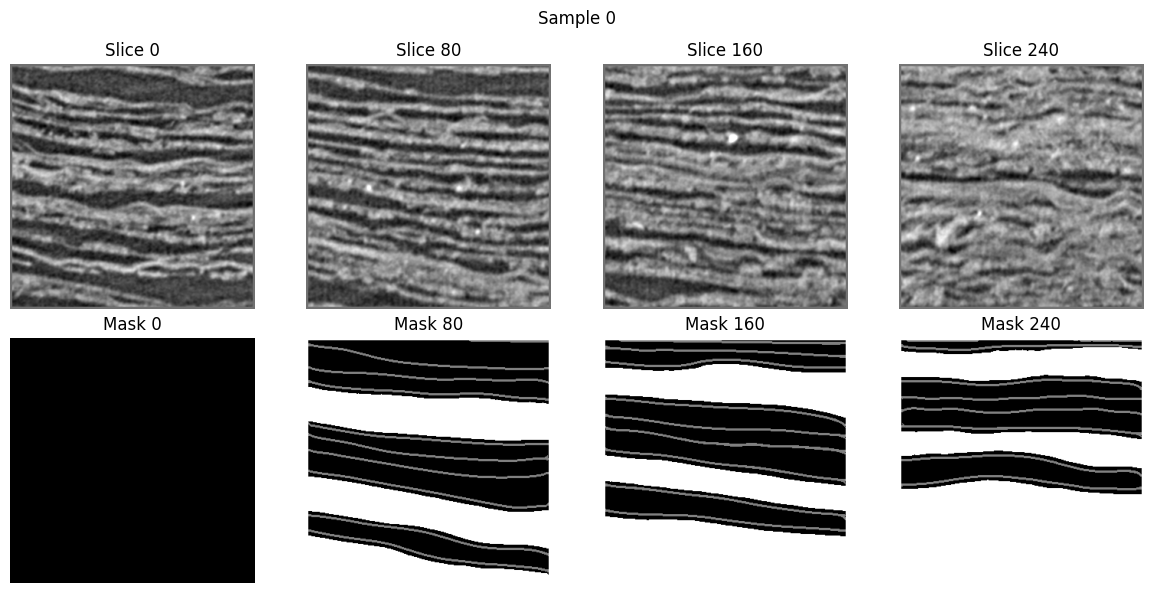

In [16]:
plot_sample(
    x, y, sample_idx=0, max_slices=4
)

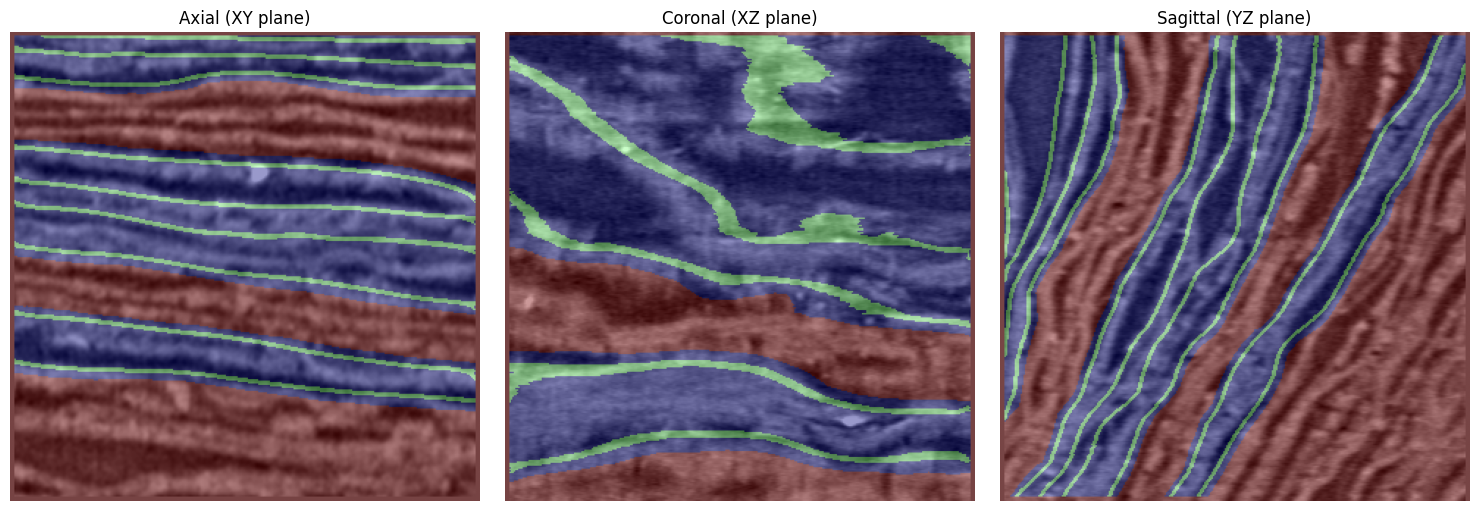

In [17]:
plot_planes(
    np.squeeze(x[0]), # picking one sample
    np.squeeze(y[0])  # picking one sample
)

## Model

In [18]:
## check available models (classification + segmentation)
# medicai.models.list_models()

In [19]:
## Pre-build encoder
#model = SegFormer(
#     input_shape=input_shape + (1,),
#     encoder_name='mit_b0',
#     classifier_activation='softmax',
#     num_classes=num_classes,
# )

# model = UPerNet(
#     input_shape=input_shape + (1,),
#     encoder_name="convnext_base",
#     classifier_activation='softmax',
#     num_classes=num_classes,
# )

model = UNETRPlusPlus(
    input_shape=input_shape + (1,),
    encoder_name='unetr_plusplus_encoder',
    classifier_activation='softmax',
    num_classes=num_classes,
)
model.count_params() / 1e6

42.648155

In [20]:
# ## Custom encoder
# # backbone with 4 skip connection
# backbone = ConvNeXtV2Tiny(
#     input_shape=input_shape + (1,),
#     include_top=False
# )
# # print(backbone.pyramid_outputs)

# # segmentator
# segmentor = TransUNet(
#     encoder=backbone,
#     encoder_depth=4,
#     num_classes=num_classes,
#     classifier_activation='softmax'
# )
# inputs = keras.Input(shape=input_shape + (1,))
# x = segmentor(inputs)

# # final supsampling, 2x tmes.
# outputs = ResizingND(
#     target_shape=input_shape,
#     interpolation='trilinear',
#     align_corners=False
# )(x)
# model = keras.Model(inputs=inputs, outputs=outputs)
# model.count_params() / 1e6

In [21]:
# ALERT: This attributes only available in medicai (not in core keras)
try:
    print(model.instance_describe())
except AttributeError:
    pass

Instance of UNETRPlusPlus
  • input_shape: (128, 128, 128, 1)
  • encoder: UNETRPlusPlusEncoder(
    • input_shape: (128, 128, 128, 1)
    • filters: [32, 64, 128, 256]
    • patch_size: (4, 4, 4)
    • spatial_reduced_tokens: [64, 64, 64, 32]
    • depths: [3, 3, 3, 3]
    • num_heads: 4
    • transformer_dropout_rate: 0.1
    )
  • encoder_name: 'unetr_plusplus_encoder'
  • num_classes: 3
  • classifier_activation: softmax
  • feature_size: 16
  • norm_name: instance


# LR Schedules and Optimizer

In [22]:
steps_per_epoch = num_samples // batch_size
total_steps = steps_per_epoch * epochs
warmup_steps = int(total_steps * 0.05)
decay_steps = max(1, total_steps - warmup_steps)
lr_schedule = CosineDecay(
    initial_learning_rate=1e-6,
    decay_steps=decay_steps,
    warmup_target=min(3e-4, 1e-4 * (batch_size / 2)),
    warmup_steps=warmup_steps,
    alpha=0.1,
)

In [23]:
# define optomizer, loss, metrics
optim = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-5,
)

loss_fn = SparseDiceCELoss(
    from_logits=False, 
    num_classes=num_classes,
    ignore_class_ids=2,
)

metrics = [
    SparseDiceMetric(
        from_logits=False, 
        num_classes=num_classes, 
        ignore_class_ids=2,
        name='dice'
    ),
]

model.compile(
    optimizer=optim,
    loss=loss_fn,
    metrics=metrics,
)

In [24]:
swi_callback_metric = SparseDiceMetric(
    from_logits=False,
    ignore_class_ids=2,
    num_classes=num_classes,
    name='val_dice',
)

swi_callback = SlidingWindowInferenceCallback(
    model,
    dataset=val_ds,
    metrics=swi_callback_metric,
    num_classes=num_classes,
    interval=5,
    overlap=0.5,
    mode='gaussian',
    roi_size=input_shape,
    sw_batch_size=1 * total_device,
    save_path="model.weights.h5"
)

In [25]:
# ALERT: Starting may take time.
model.fit(
    train_ds,
    epochs=epochs,
    callbacks=[
        swi_callback
    ]
)

Epoch 1/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 980s 3s/step - dice: 0.5989 - loss: 1.0570
Epoch 2/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 79s 765ms/step - dice: 0.6666 - loss: 0.8273
Epoch 3/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 76s 738ms/step - dice: 0.6833 - loss: 0.7669
Epoch 4/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 72s 690ms/step - dice: 0.6865 - loss: 0.7551
Epoch 5/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - dice: 0.6628 - loss: 0.7518
Epoch 5: Running inference...


Total patch 64: 100%|██████████| 8/8 [00:02<00:00,  3.06it/s]


Epoch 5: Score = 0.5369
New best score! Model saved to model.weights.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - dice: 0.6889 - loss: 0.7449 
Epoch 6/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 74s 717ms/step - dice: 0.6901 - loss: 0.7433
Epoch 7/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 72s 701ms/step - dice: 0.6901 - loss: 0.7496
Epoch 8/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 76s 733ms/step - dice: 0.6916 - loss: 0.7463
Epoch 9/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 72s 696ms/step - dice: 0.6921 - loss: 0.7486
Epoch 10/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 765ms/step - dice: 0.6907 - loss: 0.7464
Epoch 10: Running inference...


Total patch 64: 100%|██████████| 8/8 [00:02<00:00,  3.14it/s]


Epoch 10: Score = 0.5316
97/97 ━━━━━━━━━━━━━━━━━━━━ 98s 961ms/step - dice: 0.6920 - loss: 0.7469
Epoch 11/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 75s 727ms/step - dice: 0.6924 - loss: 0.7468
Epoch 12/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 71s 690ms/step - dice: 0.6925 - loss: 0.7451
Epoch 13/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 74s 720ms/step - dice: 0.6938 - loss: 0.7390
Epoch 14/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 75s 721ms/step - dice: 0.6942 - loss: 0.7422
Epoch 15/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 748ms/step - dice: 0.6868 - loss: 0.7363
Epoch 15: Running inference...


...

Epoch 190: Score = 0.6325
New best score! Model saved to model.weights.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 100s 990ms/step - dice: 0.7666 - loss: 0.6551
Epoch 191/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 80s 773ms/step - dice: 0.7636 - loss: 0.6530
Epoch 192/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 77s 746ms/step - dice: 0.7631 - loss: 0.6587
Epoch 193/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 80s 773ms/step - dice: 0.7649 - loss: 0.6541
Epoch 194/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 73s 707ms/step - dice: 0.7653 - loss: 0.6570
Epoch 195/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - dice: 0.7626 - loss: 0.6514
Epoch 195: Running inference...


Total patch 64: 100%|██████████| 8/8 [00:02<00:00,  3.35it/s]


Epoch 195: Score = 0.6321
97/97 ━━━━━━━━━━━━━━━━━━━━ 94s 922ms/step - dice: 0.7656 - loss: 0.6532
Epoch 196/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 75s 729ms/step - dice: 0.7647 - loss: 0.6571
Epoch 197/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 77s 748ms/step - dice: 0.7661 - loss: 0.6568
Epoch 198/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 79s 771ms/step - dice: 0.7655 - loss: 0.6560
Epoch 199/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 76s 742ms/step - dice: 0.7652 - loss: 0.6555
Epoch 200/200
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - dice: 0.7610 - loss: 0.6565
Epoch 200: Running inference...


Total patch 64: 100%|██████████| 8/8 [00:02<00:00,  3.28it/s]


Epoch 200: Score = 0.6347
New best score! Model saved to model.weights.h5
97/97 ━━━━━━━━━━━━━━━━━━━━ 100s 983ms/step - dice: 0.7668 - loss: 0.6502


## Eval

In [26]:
model.load_weights(
    "model.weights.h5"
)
swi = SlidingWindowInference(
    model,
    num_classes=num_classes,
    roi_size=input_shape,
    mode='gaussian',
    sw_batch_size=1 * total_device,
    overlap=0.5,
)

In [27]:
dice = SparseDiceMetric(
    from_logits=False,
    num_classes=num_classes,
    ignore_class_ids=2,
    name='dice',
)

In [28]:
for sample in val_ds:
    x, y = sample
    output = swi(x)
    y = ops.convert_to_tensor(y)
    output = ops.convert_to_tensor(output)
    dice.update_state(y, output)

dice_score = float(ops.convert_to_numpy(dice.result()))
print(f"Dice Score: {dice_score:.4f}")
dice.reset_state()

Total patch 64: 100%|██████████| 8/8 [00:02<00:00,  3.19it/s]


Dice Score: 0.6410


In [29]:
x, y = next(iter(val_ds))
x.shape, y.shape

(TensorShape([1, 320, 320, 320, 1]), TensorShape([1, 320, 320, 320, 1]))

In [30]:
y_pred = swi(x)
y_pred.shape

Total patch 64: 100%|██████████| 8/8 [00:02<00:00,  3.20it/s]


(1, 320, 320, 320, 3)

In [31]:
segment = y_pred.argmax(-1).astype(np.uint8)
segment.shape, np.unique(segment)

((1, 320, 320, 320), array([0, 1], dtype=uint8))

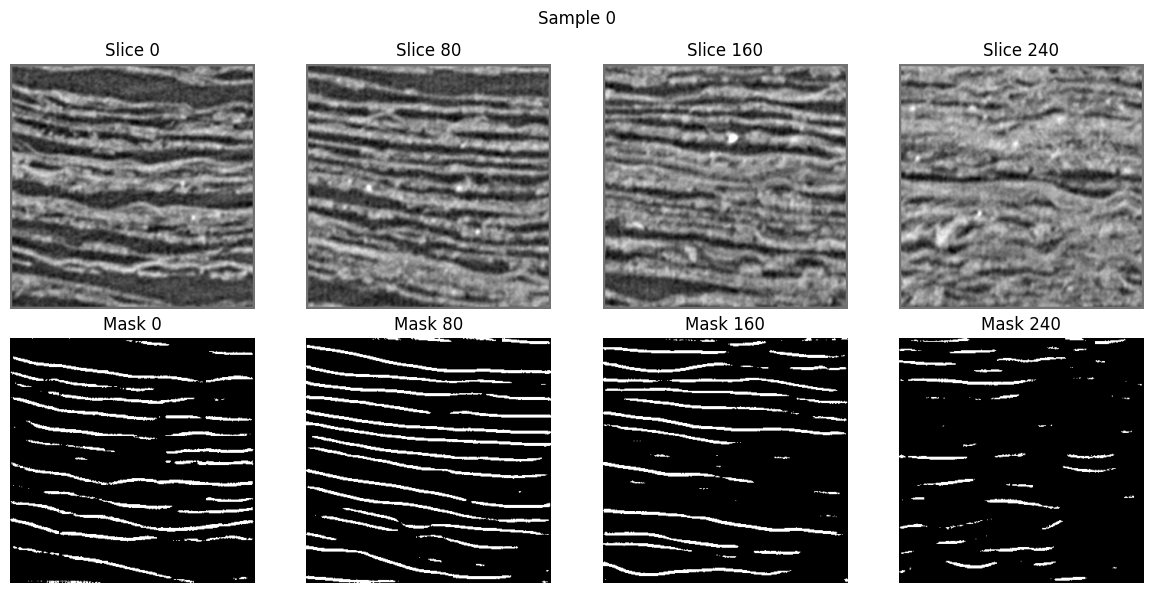

In [32]:
plot_sample(
    x, segment, sample_idx=0, max_slices=4
)

**Next Stop**

- [Affinity Feature Strengthening](https://arxiv.org/pdf/2211.06578)
- [Meta-Tubular-Net: A Robust Topology-Aware Re-Weighting Network](file:///C:/Users/ASUS/Pictures/Screenshots/ssrn-4132287.pdf)
- [Landmark-Assisted Anatomy-Sensitive](file:///C:/Users/ASUS/Downloads/diagnostics-13-02260-v2.pdf)
- [LEAD: Self-Supervised Landmark Estimation](https://arxiv.org/pdf/2204.02958)
- [TopoSeg: Topology-Aware](https://openaccess.thecvf.com/content/ICCV2023/papers/He_TopoSeg_Topology-Aware_Nuclear_Instance_Segmentation_ICCV_2023_paper.pdf)
- [Virtually Unrolling the Herculaneum Papyri](https://arxiv.org/pdf/2512.04927v1)